# Exercise 03 - Netflix Plots

Use markdown or comments to indicate exercise numbers. Fill each code cell with your solution.

Dataset: `dataset/titles.csv`

In [125]:
# Optional setup cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Load the Dataset

Read the Netflix Movies and TV Shows dataset from `dataset/titles.csv` using Pandas.

In [126]:
# Write your solution here

df = pd.read_csv("dataset/titles.csv")
df = df[df["release_year"] >= 2000]
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
105,ts20981,Survivor,SHOW,A reality show contest where sixteen or more c...,2000,TV-PG,48,['reality'],['US'],42.0,tt0239195,7.4,24368.0,73.107,7.3
116,ts21567,Gilmore Girls,SHOW,"Set in the charming town of Stars Hollow, Conn...",2000,TV-14,46,"['comedy', 'drama']",['US'],8.0,tt0238784,8.2,119054.0,51.125,7.8
134,ts21034,InuYasha,SHOW,Kagome Higurashi is a modern day young girl wh...,2000,TV-14,25,"['action', 'comedy', 'scifi', 'animation', 'dr...",['JP'],9.0,tt0290223,7.9,15823.0,149.742,8.6
139,tm19673,The Patriot,MOVIE,After proving himself on the field of battle i...,2000,R,165,"['drama', 'action', 'history', 'war']","['DE', 'US']",NaN,tt0187393,7.2,270231.0,20.438,7.1
140,tm24877,Road Trip,MOVIE,From the director of the Hangover trilogy and ...,2000,R,93,['comedy'],['US'],NaN,tt0215129,6.5,167670.0,16.989,6.2


## 1. Line Plot - Number of SHOWs Over the Years

Create a line plot showing the evolution of the number of `SHOW`s over the years.

- The y-axis should show the total number of `SHOW`s released in a given year.
- The x-axis should show the release year from the `release_year` column.
- Aim for a clear and creative visualization.

Example from the PDF:

![Example line plot](images/question-01-line-plot-example.png)

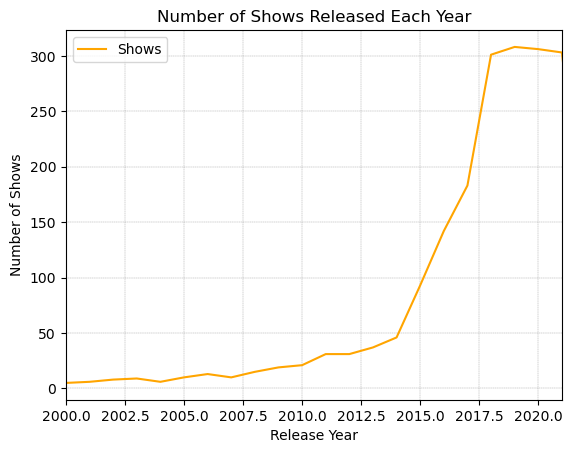

In [127]:
# Write your solution here
data = df[df['type'] == "SHOW"]['release_year'].value_counts().sort_index()
plt.xlabel("Release Year")
plt.ylabel("Number of Shows")
plt.xlim(2000, 2021)
plt.plot(data, linestyle='-', color='orange')
plt.legend(["Shows"])
plt.title("Number of Shows Released Each Year")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.25)
plt.show()

## 2. Line Plot - SHOWs and MOVIEs Over the Years

Considering the previous line plot, add a line representing the total number of `MOVIE`s released over the years.

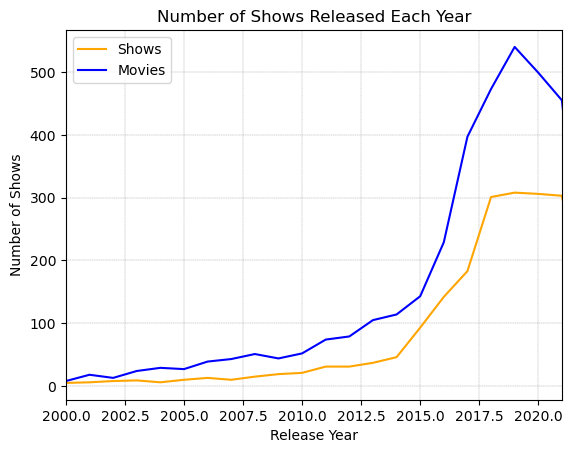

In [128]:
# Write your solution here
df_shows = df[df['type'] == "SHOW"]['release_year'].value_counts().sort_index()
df_movies = df[df['type'] == "MOVIE"]['release_year'].value_counts().sort_index()
plt.xlabel("Release Year")
plt.ylabel("Number of Shows")
plt.xlim(2000, 2021)
plt.plot(df_shows, linestyle='-', color='orange', label="Shows")
plt.plot(df_movies, linestyle='-', color='blue', label="Movies")
plt.legend(["Shows", "Movies"])
plt.title("Number of Shows Released Each Year")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.25)
plt.show()

## 3. Bar Chart - Number of SHOWs by Age Certification

Create a bar chart showing the number of `SHOW`s according to age certification.

- The y-axis should show the total number of `SHOW`s.
- The x-axis should show each of the 6 distinct age certifications.
- The plot does not need to have the same colors or appearance as the example in the PDF.

Example from the PDF:

![Example bar chart](images/question-03-bar-chart-example.png)

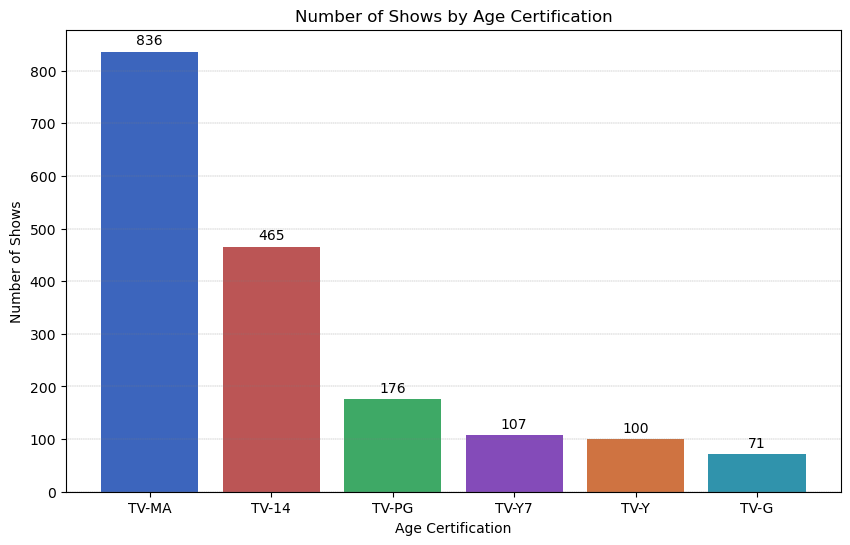

In [129]:
# Write your solution here
data = df[df["type"] == "SHOW"]["age_certification"].dropna().value_counts().sort_index().reindex(["TV-MA", "TV-14", "TV-PG", "TV-Y7", "TV-Y", "TV-G"], fill_value=0)

plt.figure(figsize=(10, 6))
plt.xlabel("Age Certification")
plt.ylabel("Number of Shows")
colors = ["#3C65BD", "#BB5555", "#3EA966", "#844BB9", "#CF7341", "#3093AC"]
plt.bar(data.index, data.values, color=colors)
plt.title("Number of Shows by Age Certification")
plt.grid(color="gray", linestyle="--", linewidth=0.25, axis="y")
plt.bar_label(plt.bar(data.index, data.values, color=colors), padding=3)
plt.show()


## 4. Grouped Bar Chart - SHOWs and MOVIEs by Age Certification

Considering the previous plot, create a grouped bar chart by adding a bar for `MOVIE`s.

Your graph should have two bars per age certification:

- one for the total number of `SHOW`s
- one for the total number of `MOVIE`s

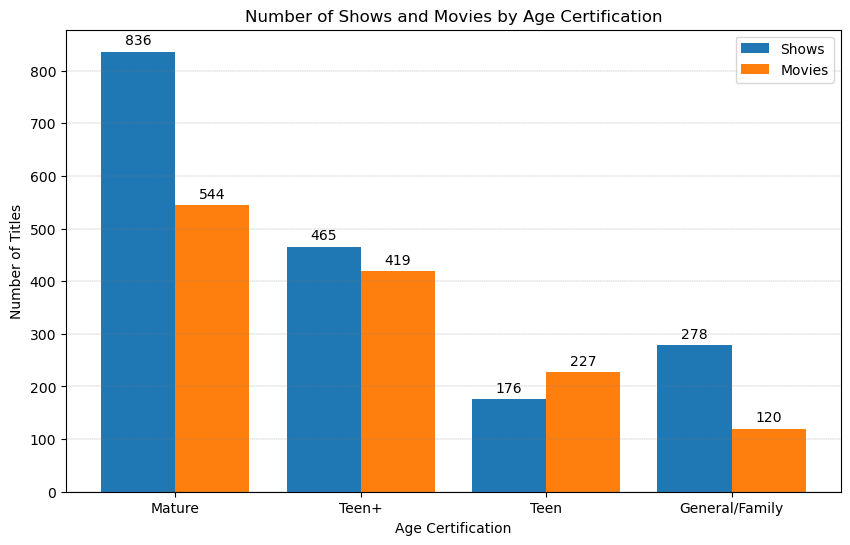

In [130]:
categories = ["Mature", "Teen+", "Teen", "General/Family"]
# Since the rating systems for Movies and Shows are different we have to rename the age certifications 
# we will make them both fit into the same categories to be able to compare them.
rating_map = {
    # General / Family / Kids
    "TV-Y": "General/Family",
    "TV-Y7": "General/Family",
    "G": "General/Family",
    "TV-G": "General/Family",
    
    # Parental Guidance
    "PG": "Teen",
    "TV-PG": "Teen",
    
    # Teens / Mature Teens
    "PG-13": "Teen+",
    "TV-14": "Teen+",
    
    # Mature
    "R": "Mature",
    "TV-MA": "Mature",
    "NC-17": "Mature"
}

data_movies = (
    df[df["type"] == "MOVIE"]["age_certification"]
    .dropna()
    .map(rating_map)
    .value_counts()
    .reindex(categories, fill_value=0)
)

data_shows = (
    df[df["type"] == "SHOW"]["age_certification"]
    .dropna()
    .map(rating_map)
    .value_counts()
    .reindex(categories, fill_value=0)
)

x = np.arange(len(categories))
bar_width = 0.4

plt.figure(figsize=(10, 6))

bars_shows = plt.bar(
    x - bar_width / 2,
    data_shows.values,
    width=bar_width,
    label="Shows"
)

bars_movies = plt.bar(
    x + bar_width / 2,
    data_movies.values,
    width=bar_width,
    label="Movies"
)

plt.xticks(x, categories)
plt.xlabel("Age Certification")
plt.ylabel("Number of Titles")
plt.title("Number of Shows and Movies by Age Certification")
plt.grid(color="gray", linestyle="--", linewidth=0.25, axis="y")
plt.legend()

plt.bar_label(bars_shows, padding=3)
plt.bar_label(bars_movies, padding=3)

plt.show()


## 5. Scatter Plot - Average Runtime Over Release Years

Create a scatter plot showing the evolution of the average runtime of `MOVIE`s and `SHOW`s over the release years.

- The y-axis should show the average runtime from the `runtime` column.
- The x-axis should show the release year.
- Use a color map to indicate which points represent movies and which points represent shows.

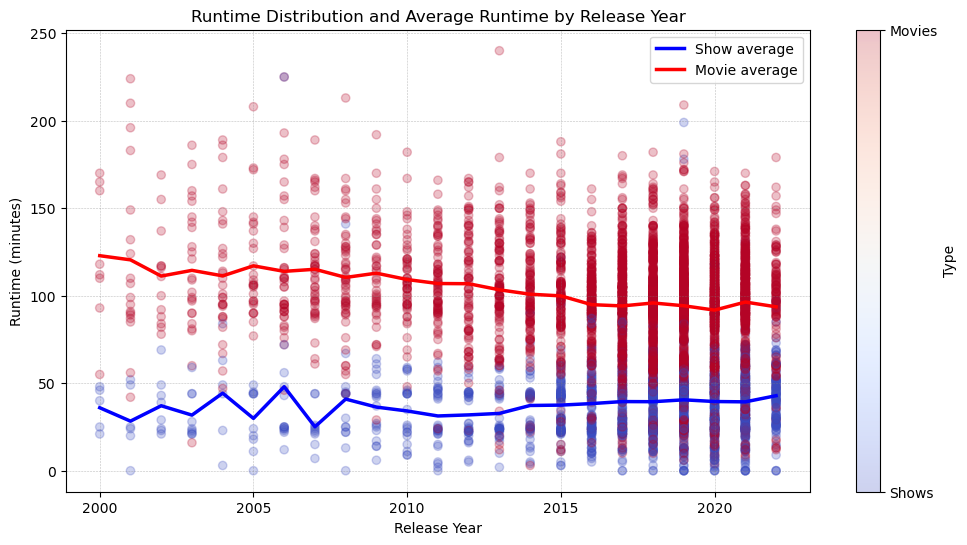

In [131]:

plot_data = (
    df[df["type"].isin(["MOVIE", "SHOW"])]
    .dropna(subset=["release_year", "runtime"])
    .copy()
)

plot_data["type_code"] = plot_data["type"].map({
    "MOVIE": 1,
    "SHOW": 0
})

avg_runtime = (
    plot_data
    .groupby(["release_year", "type"], as_index=False)["runtime"]
    .mean()
)

avg_movies = avg_runtime[avg_runtime["type"] == "MOVIE"]
avg_shows = avg_runtime[avg_runtime["type"] == "SHOW"]

plt.figure(figsize=(12, 6))

scatter = plt.scatter(
    plot_data["release_year"],
    plot_data["runtime"],
    c=plot_data["type_code"],
    cmap="coolwarm",
    alpha=0.25
)

plt.plot(
    avg_shows["release_year"],
    avg_shows["runtime"],
    color="blue",
    linewidth=2.5,
    label="Show average"
)

plt.plot(
    avg_movies["release_year"],
    avg_movies["runtime"],
    color="red",
    linewidth=2.5,
    label="Movie average"
)


colorbar = plt.colorbar(scatter)
colorbar.set_ticks([0, 1])
colorbar.set_ticklabels(["Shows", "Movies"])
colorbar.set_label("Type")

plt.title("Runtime Distribution and Average Runtime by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Runtime (minutes)")
plt.grid(color="gray", linestyle="--", linewidth=0.4, alpha=0.5)
plt.legend()
plt.show()


## 6. Histograms - Runtime Distribution for MOVIEs and SHOWs

Generate two histograms:

- the first showing the distribution of the runtime of `MOVIE`s
- the second showing the distribution of the runtime of `SHOW`s

Select a bin size that you believe best represents the data, but use the same bin size for both graphs.

Attention: You may need to clean null values to generate some of the graphs.

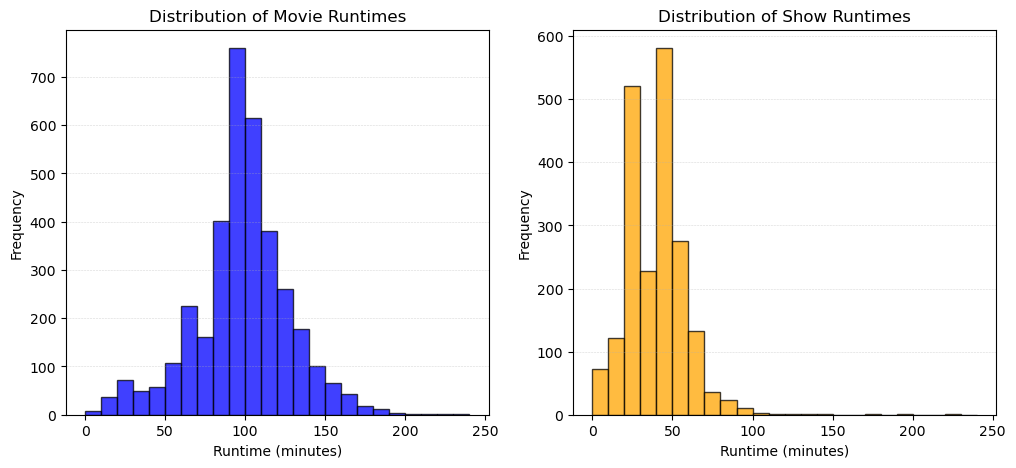

In [132]:
# Write your solution here
movies_runtime = df[df["type"] == "MOVIE"]["runtime"].dropna()
shows_runtime = df[df["type"] == "SHOW"]["runtime"].dropna()

bin_size = 10
bins = range(
    int(min(movies_runtime.min(), shows_runtime.min())),
    int(max(movies_runtime.max(), shows_runtime.max())) + bin_size,
    bin_size
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(movies_runtime, bins=bins, color="blue", alpha=0.75, edgecolor="black")
plt.title("Distribution of Movie Runtimes")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)

plt.subplot(1, 2, 2)
plt.hist(shows_runtime, bins=bins, color="orange", alpha=0.75, edgecolor="black")
plt.title("Distribution of Show Runtimes")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
plt.show()
